In [2]:
#load packages
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import numpy as np
import functions.missing_labs as ml
import functions.eda_model as em

In [4]:
# load dataset
df = ml.load_data("cleaned_dataset_all_vars.csv")

Loaded dataset with shape: (1611, 13)


## In the EDA.ipynb file, we provide preliminary statistical characteristics of the lab tests. In our dataset, the 'PerformedDate' column represents the specific date when each patient underwent a lab test after being diagnosed with bipolar disorder. We aim to analyze the trend of their lab test results over time.

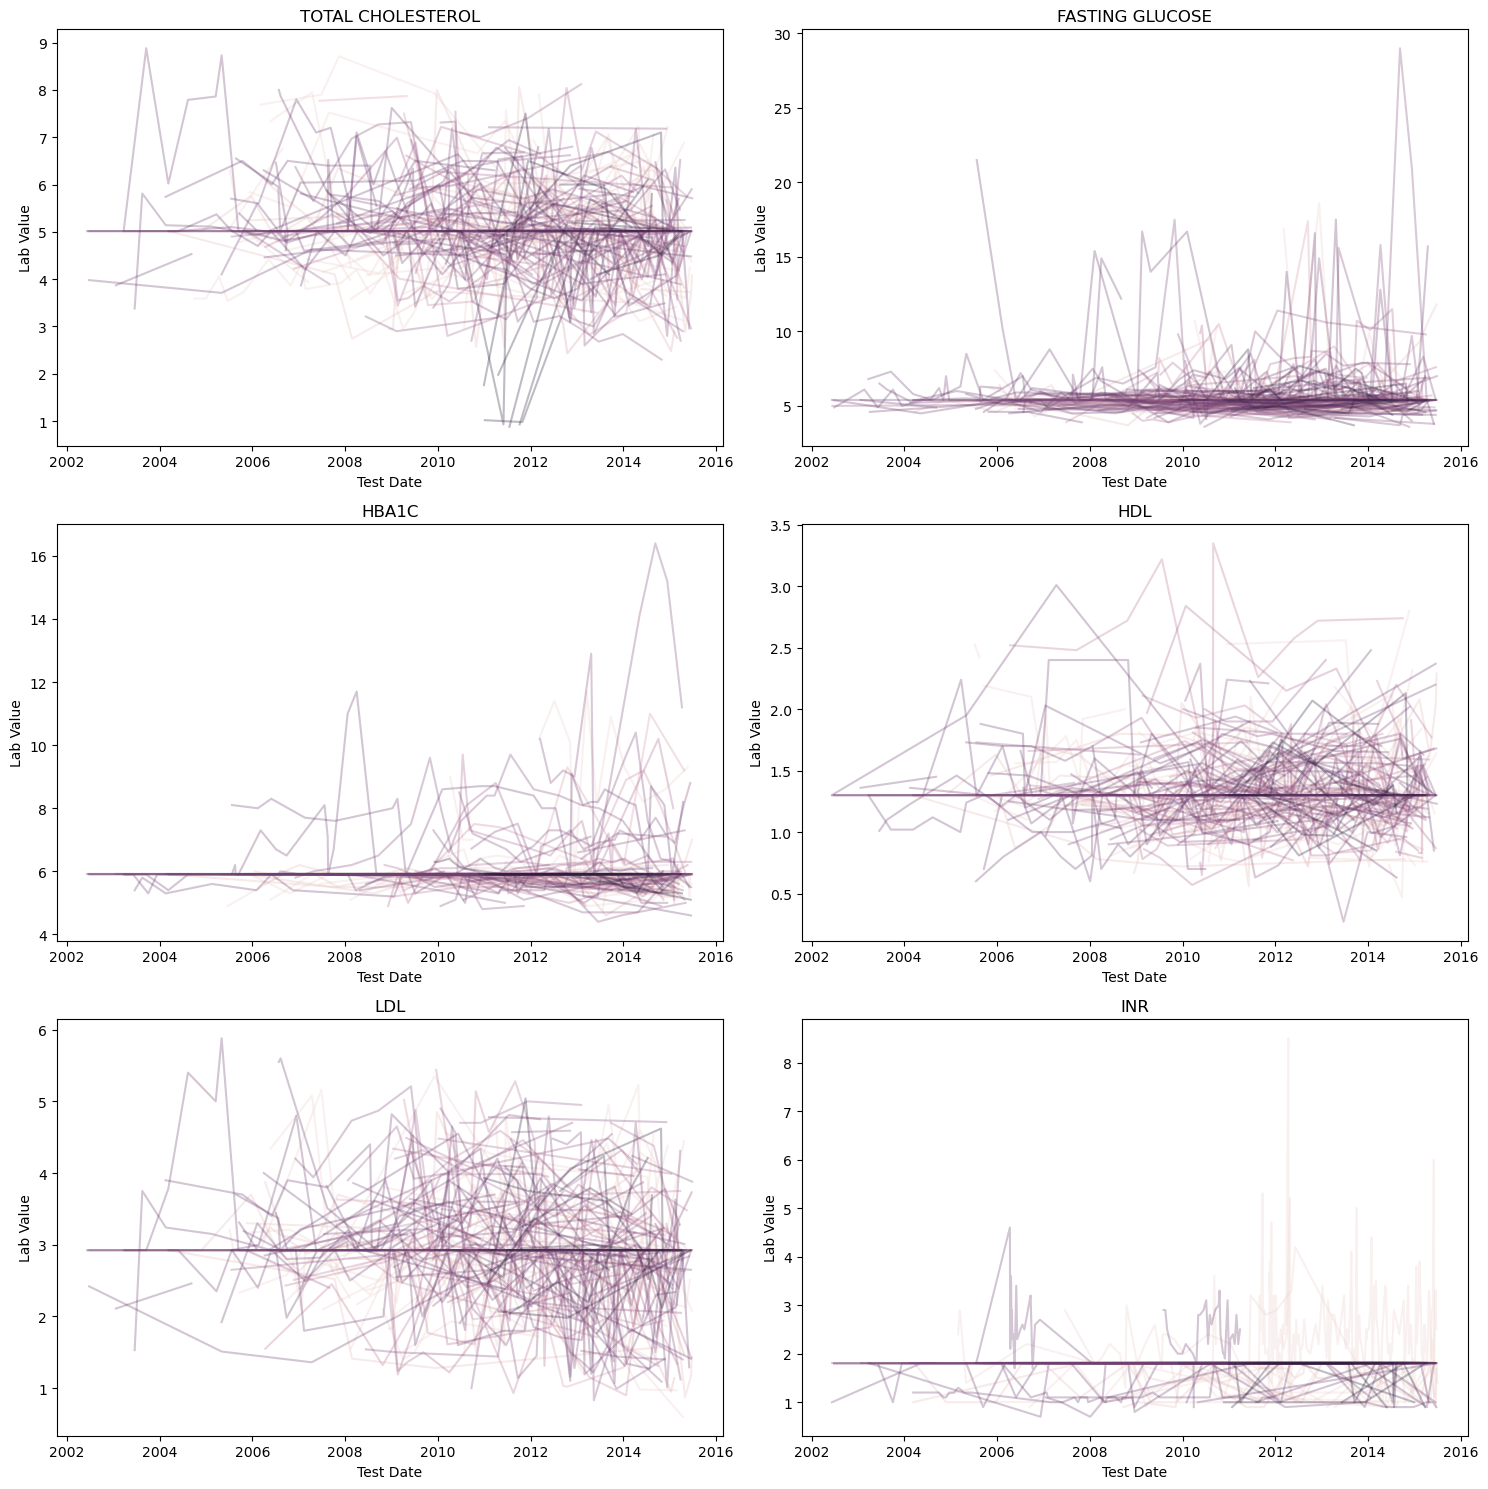

In [5]:
em.plot_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    date='PerformedDate',
    hue='Patient_ID',
    xlabel='Test Date',
    ylabel='Lab Value'
)

## After generating the trajectory plots using actual dates, we found the patterns to be quite messy and difficult to interpret. To address this, we standardized the 'PerformedDate' by converting it to a 'VisitOrder' variable—grouping by patient and ordering their lab test records chronologically.

In [6]:
df = df.sort_values(['Patient_ID', 'PerformedDate'])
df['VisitOrder'] = df.groupby('Patient_ID').cumcount() + 1

## How many individuals are present at each visit?

Descriptive statistics of total visits per patient:
count    293.000000
mean       5.498294
std       12.221871
min        1.000000
25%        1.000000
50%        3.000000
75%        6.000000
max      189.000000
Name: TotalVisits, dtype: float64

Frequency distribution of total visits:
TotalVisits
1      89
2      57
3      27
4      23
5      14
6      13
7      14
8       4
9       9
10      8
11      9
12      3
13      2
14      1
15      2
16      2
17      1
19      2
20      2
21      1
25      2
26      2
28      3
33      1
35      1
189     1
Name: count, dtype: int64


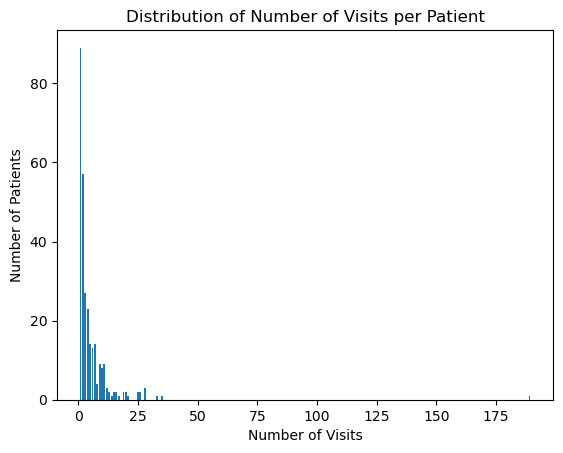

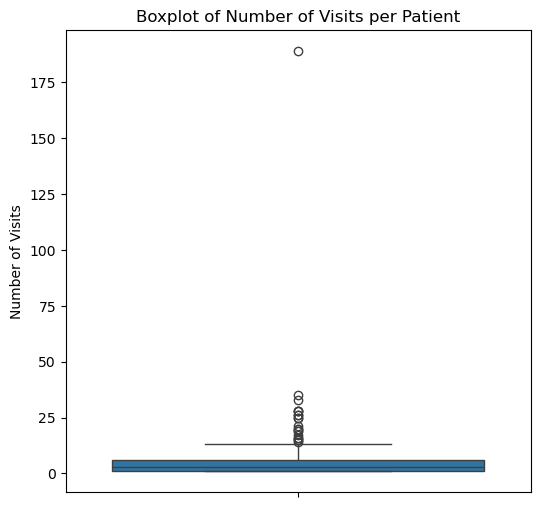

In [7]:
# Calculate the total number of visits per patient
visit_counts = df.groupby('Patient_ID')['VisitOrder'].max().reset_index(name='TotalVisits')

# Descriptive statistics
print("Descriptive statistics of total visits per patient:")
print(visit_counts['TotalVisits'].describe())

# Frequency distribution
print("\nFrequency distribution of total visits:")
print(visit_counts['TotalVisits'].value_counts().sort_index())

# Histogram of Number of Visits per Patient
plt.hist(visit_counts['TotalVisits'], bins=range(1, visit_counts['TotalVisits'].max()+2), align='left', rwidth=0.8)
plt.xlabel('Number of Visits')
plt.ylabel('Number of Patients')
plt.title('Distribution of Number of Visits per Patient')
plt.show()

# Boxplot of Number of Visits per Patient
plt.figure(figsize=(6, 6))
sns.boxplot(y=visit_counts['TotalVisits'])
plt.title('Boxplot of Number of Visits per Patient')
plt.ylabel('Number of Visits')
plt.show()

## On average, patients have 5 visits. There are 9 patients who each had 11 visits.

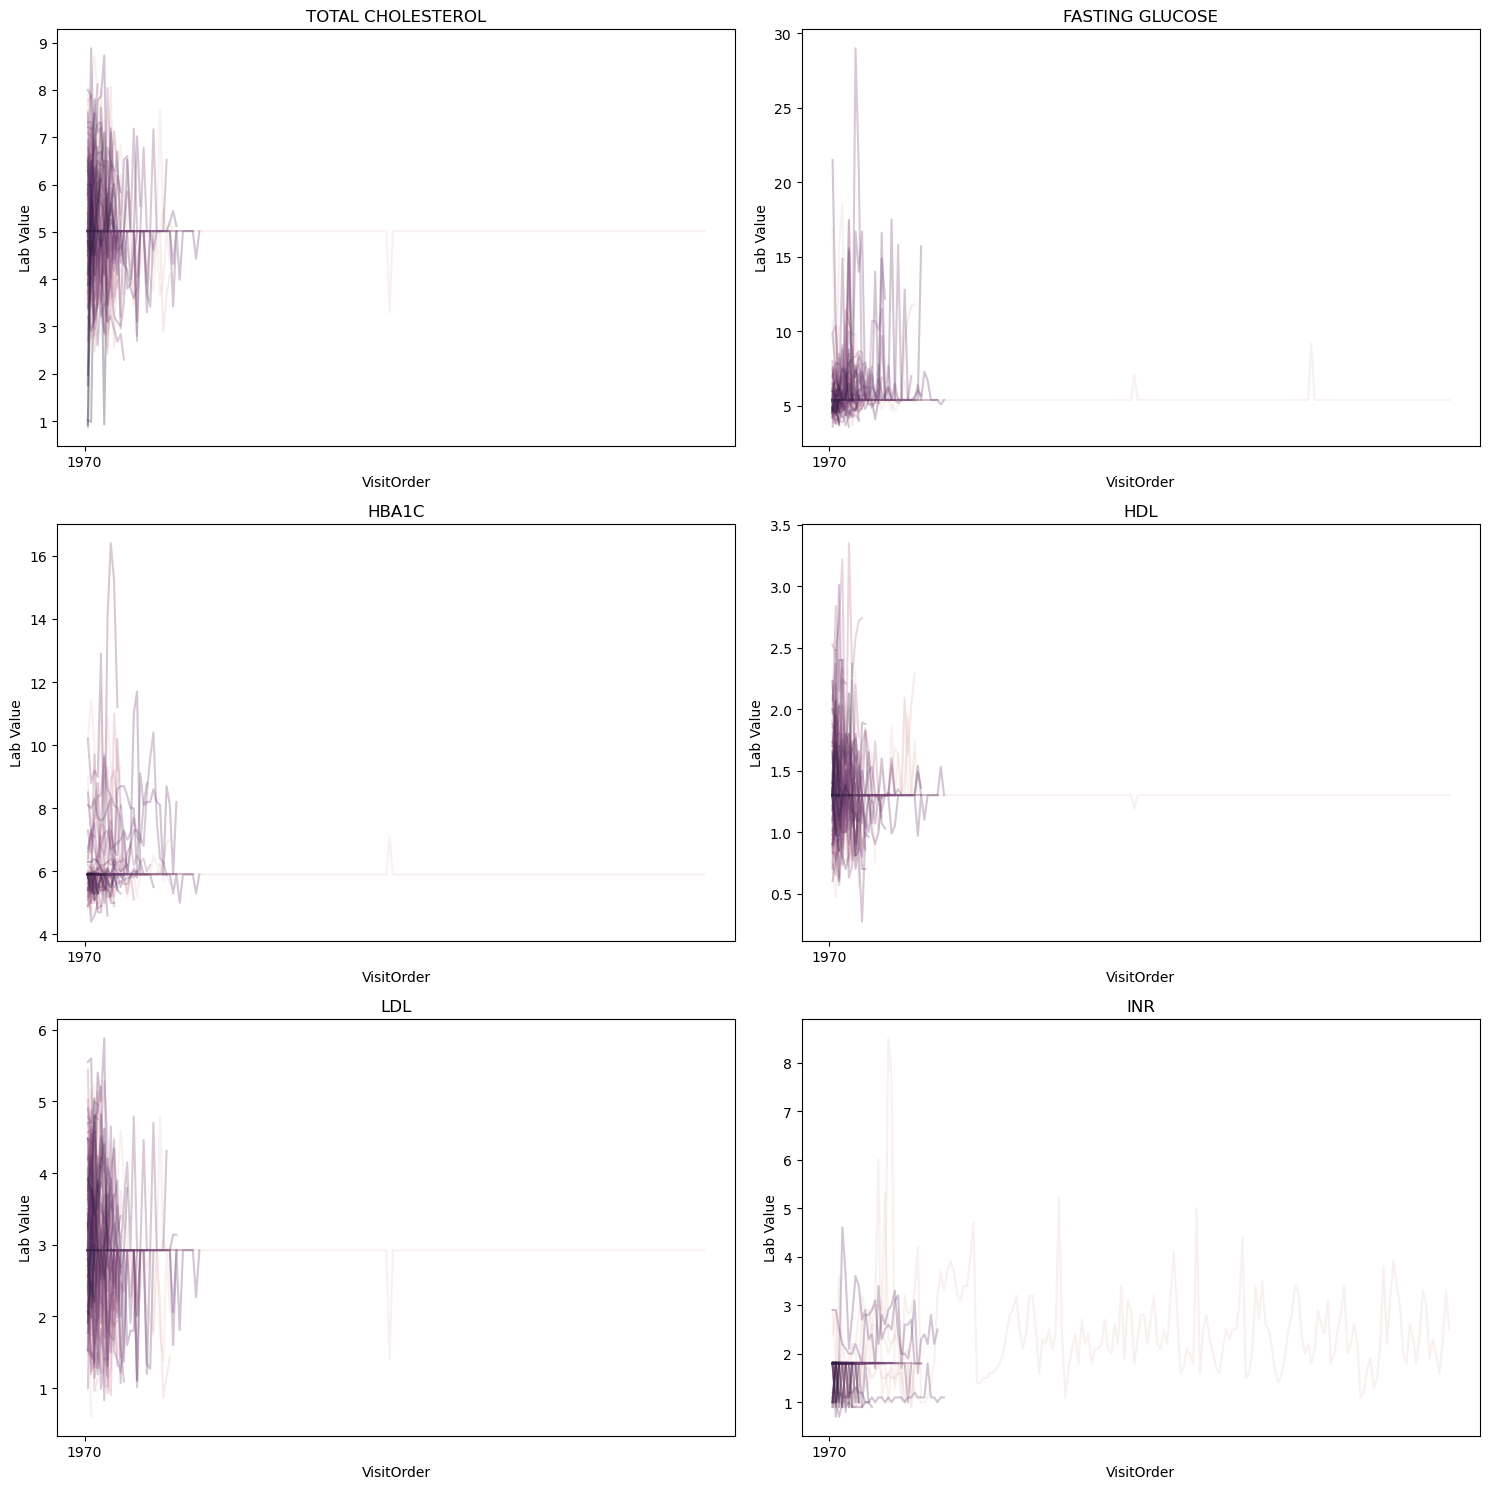

In [14]:
em.plot_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    date='VisitOrder',
    hue='Patient_ID',
    xlabel='VisitOrder',
    ylabel='Lab Value'
)

## We observe that most individuals have up to 25 visits. Therefore, by focusing on data from the first 25 visits, we can gain more insight into the characteristics of their lab test results.

/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[date] = pd.to_datetime(data[date])


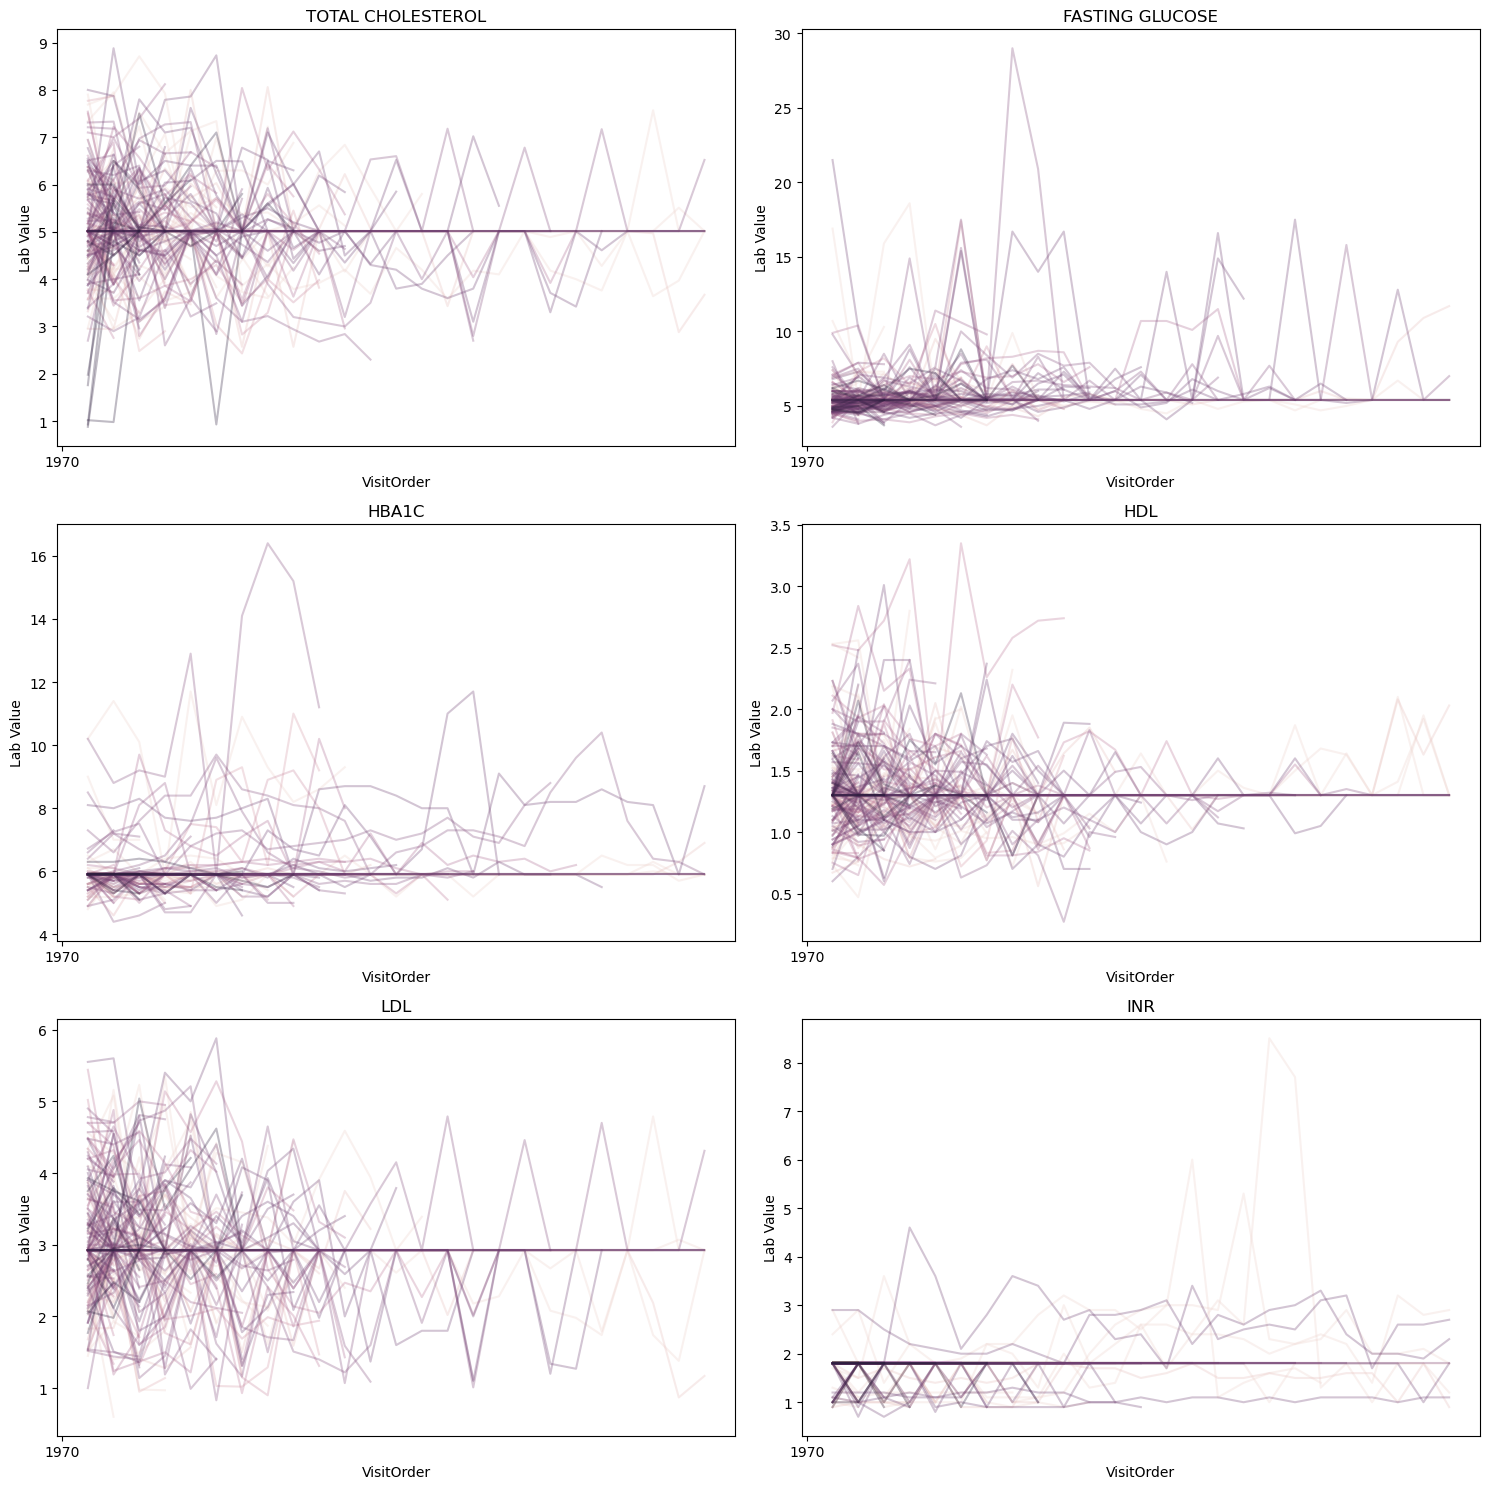

In [13]:
# keep first 25 visits
df_25 = df[df['VisitOrder'] <= 25]
em.plot_trends(
    data=df_25,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    date='VisitOrder',
    hue='Patient_ID',
    xlabel='VisitOrder',
    ylabel='Lab Value'
)

In [138]:
lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

corr_matrix = df[lab_vars].corr()

print(corr_matrix)


                   TOTAL CHOLESTEROL  FASTING GLUCOSE     HBA1C       HDL  \
TOTAL CHOLESTEROL           1.000000        -0.075347 -0.047125  0.159656   
FASTING GLUCOSE            -0.075347         1.000000  0.473909 -0.091966   
HBA1C                      -0.047125         0.473909  1.000000 -0.080046   
HDL                         0.159656        -0.091966 -0.080046  1.000000   
LDL                         0.782300        -0.130486 -0.090317  0.014333   
INR                         0.014615        -0.021287 -0.005984 -0.003081   
GLUCOSE TOLERANCE                NaN              NaN       NaN       NaN   

                        LDL       INR  GLUCOSE TOLERANCE  
TOTAL CHOLESTEROL  0.782300  0.014615                NaN  
FASTING GLUCOSE   -0.130486 -0.021287                NaN  
HBA1C             -0.090317 -0.005984                NaN  
HDL                0.014333 -0.003081                NaN  
LDL                1.000000  0.022787                NaN  
INR                0.022787  

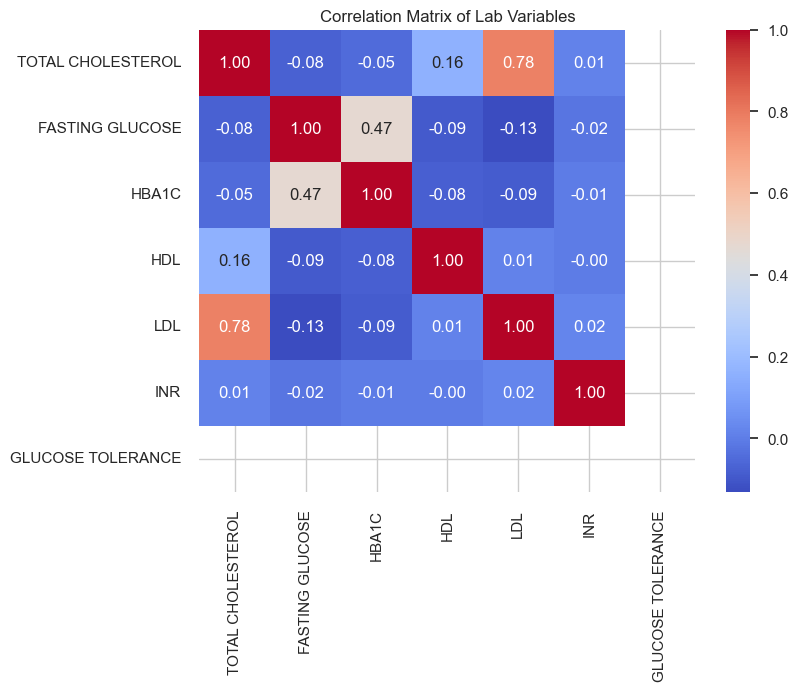

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Lab Variables')
plt.show()

## To be specific, bipolar disorder has various subtypes, so we examine the lab test results corresponding to each subtype. There are seven subtypes of bipolar disorder, which are described below.

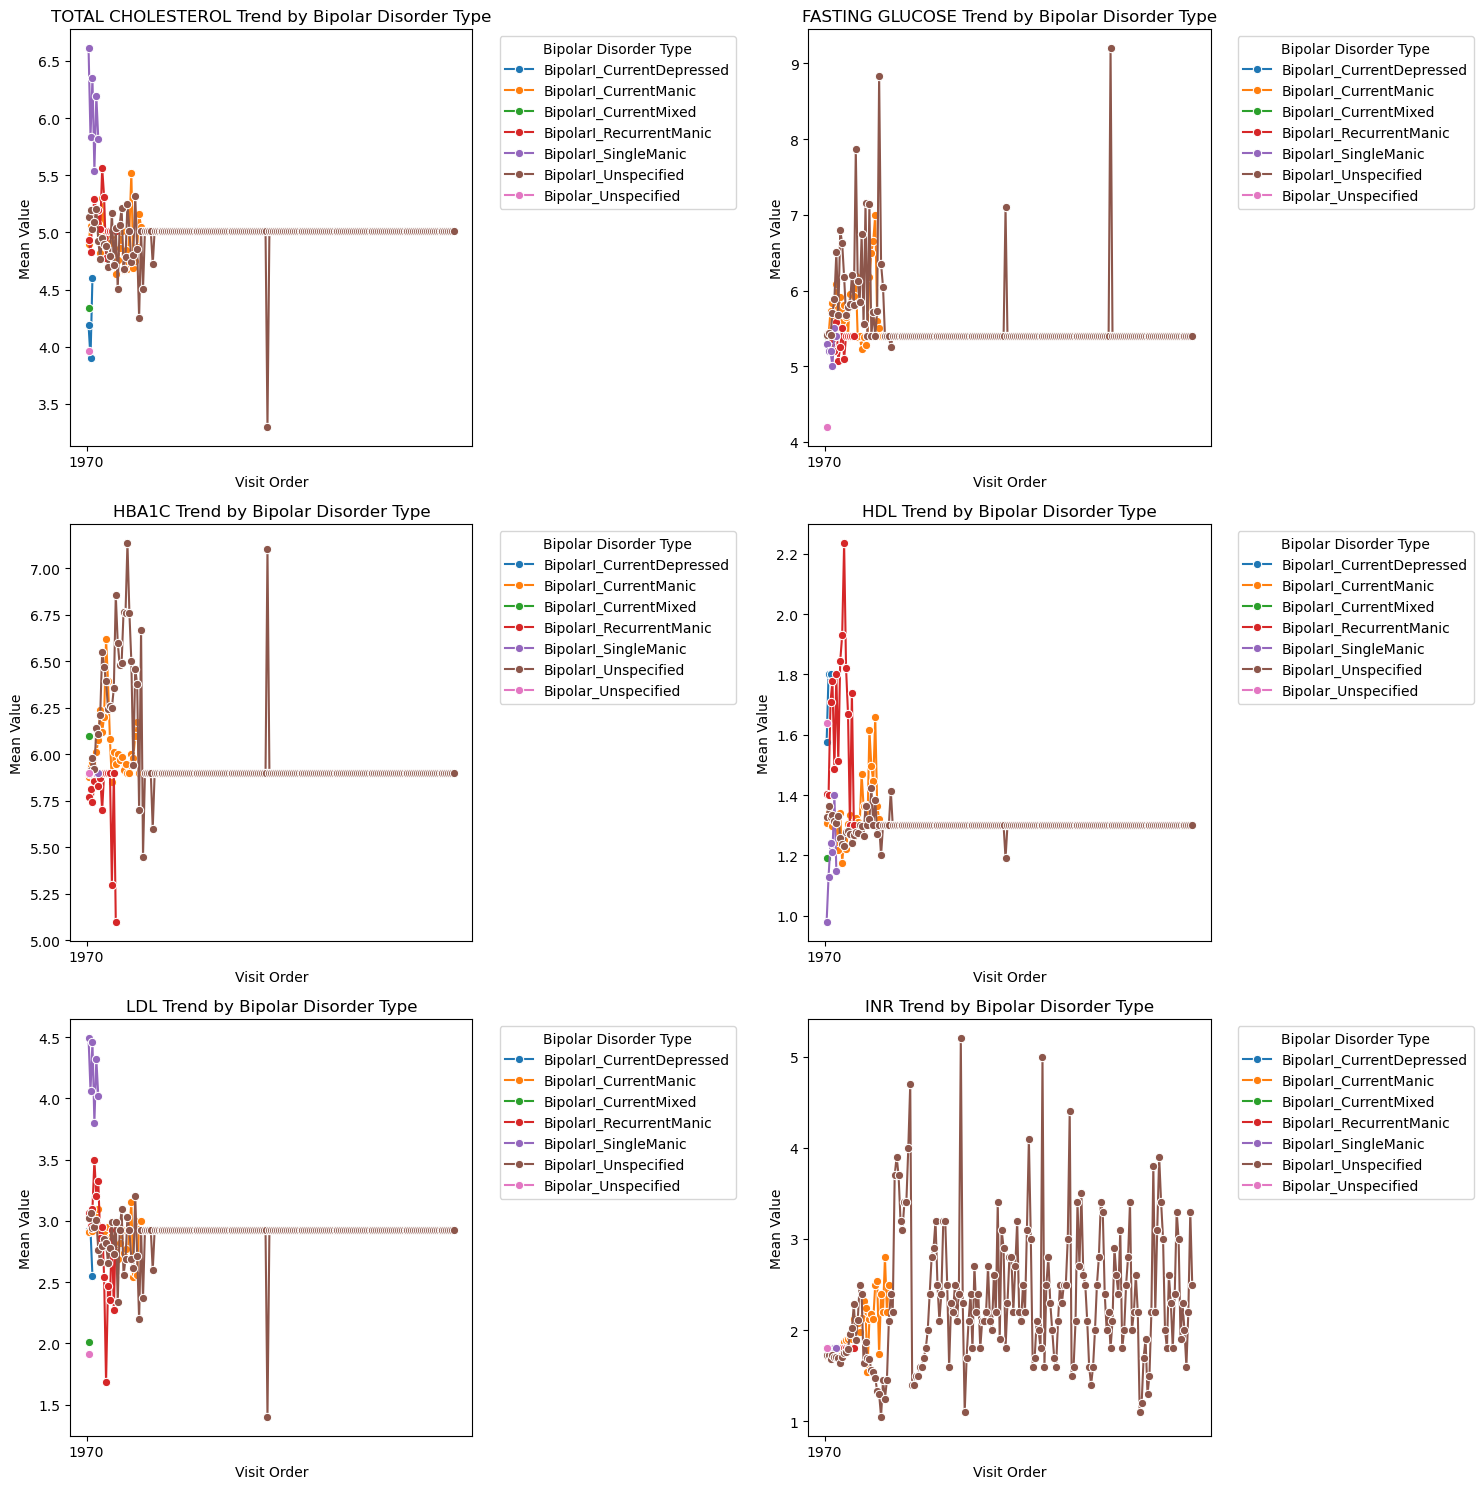

In [15]:
# mapping & encode subtypes of bipolar disorders
bipolar_map = {
    '296.0': 'BipolarI_SingleManic',
    '296.1': 'BipolarI_RecurrentManic',
    '296.4': 'BipolarI_CurrentManic',
    '296.5': 'BipolarI_CurrentDepressed',
    '296.6': 'BipolarI_CurrentMixed',
    '296.7': 'BipolarI_Unspecified',
    '296.8': 'Bipolar_Unspecified'
}

bipolar_order = [
    'BipolarI_SingleManic',
    'BipolarI_RecurrentManic',
    'BipolarI_CurrentManic',
    'BipolarI_CurrentDepressed',
    'BipolarI_CurrentMixed',
    'BipolarI_Unspecified',
    'Bipolar_Unspecified'
]

df = em.map_encode(
    data=df,
    code='DiagnosisCode_calc',
    mapping_dict=bipolar_map,
    ordered_levels=bipolar_order,
    new_label='Bipolar Disorder Type',
    new_factor='Bipolar Disorder Type Factor',
    new_num='Bipolar Disorder Type Num'
)
# visualize grouped trajctory of subtypes of bipolar disorders
em.plot_grouped_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    group_x='VisitOrder',
    group_hue='Bipolar Disorder Type',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)

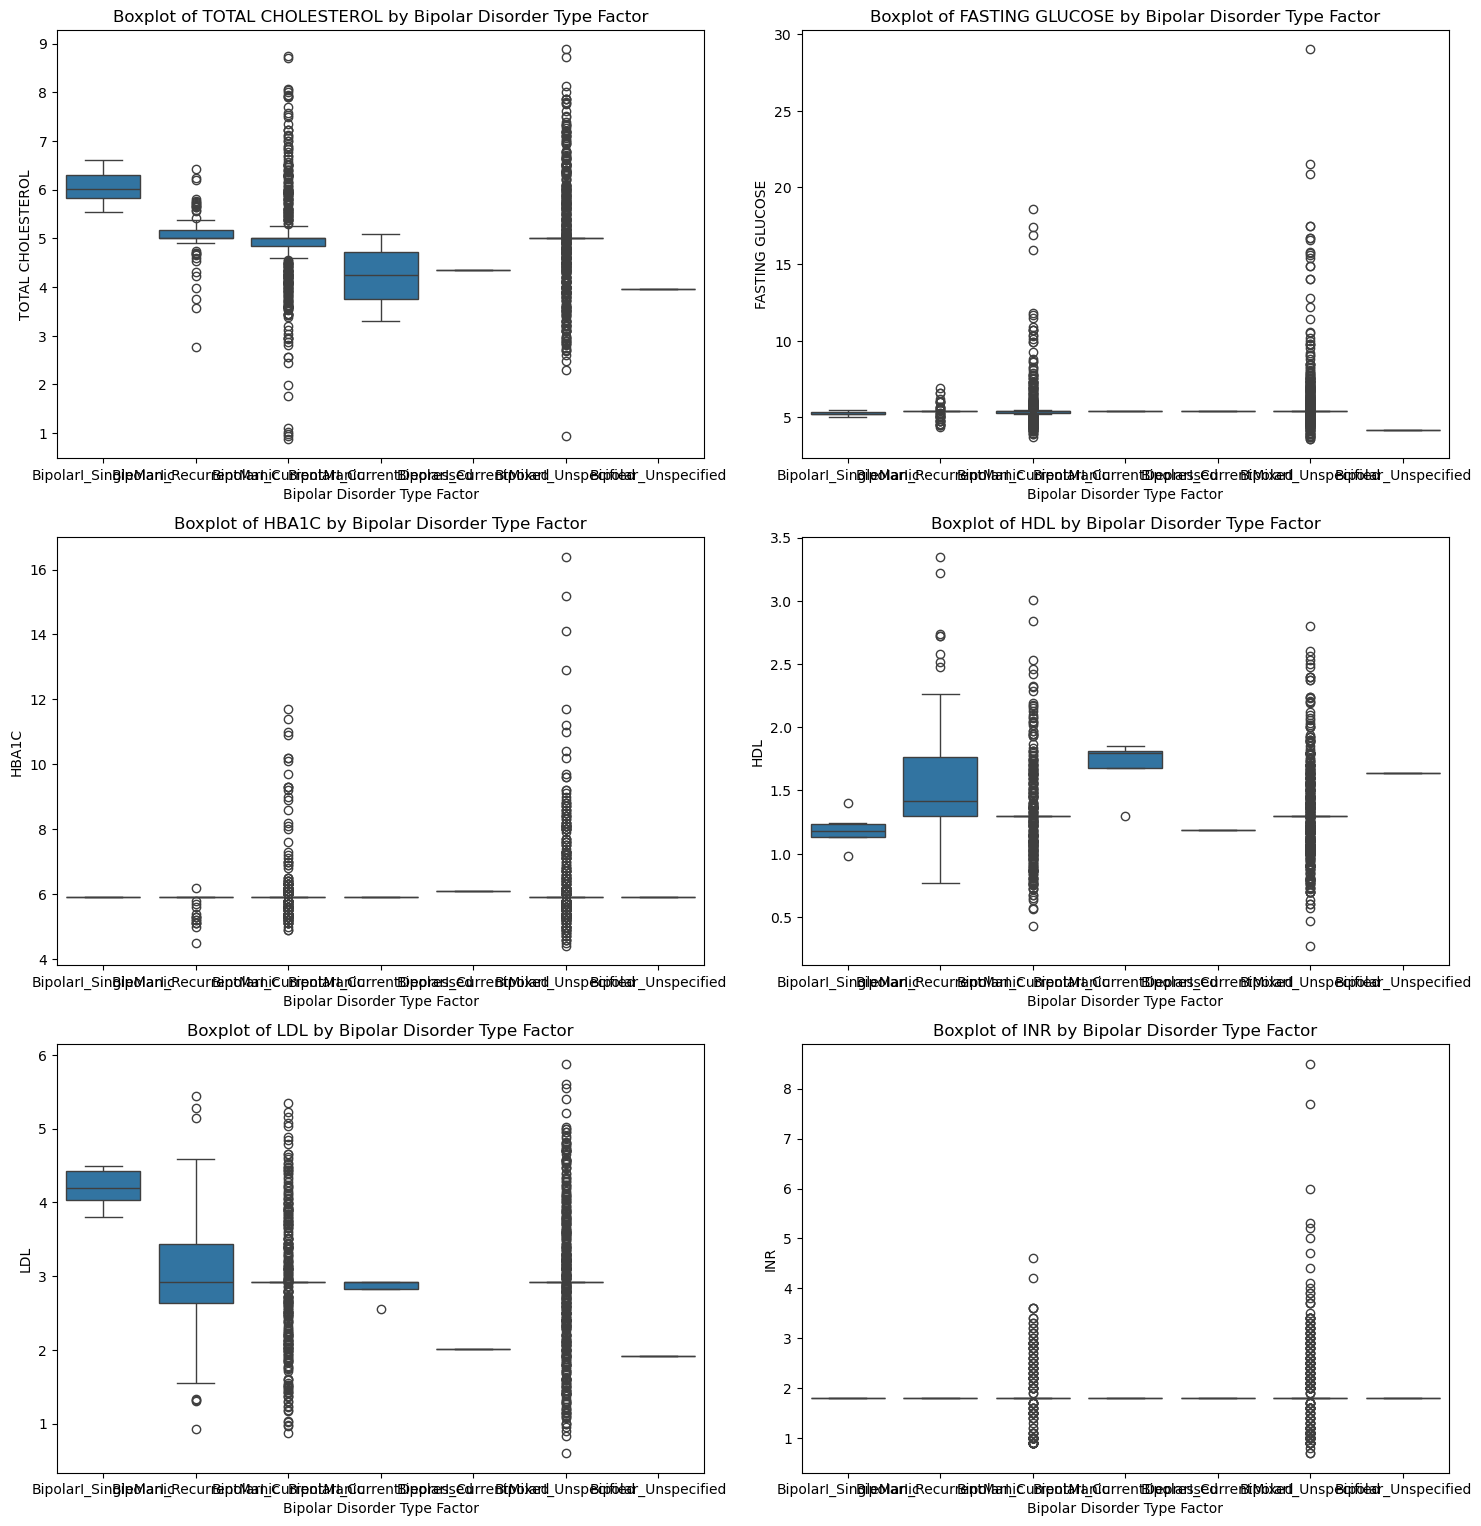

In [16]:
em.plot_grouped_boxplots(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='Bipolar Disorder Type Factor')

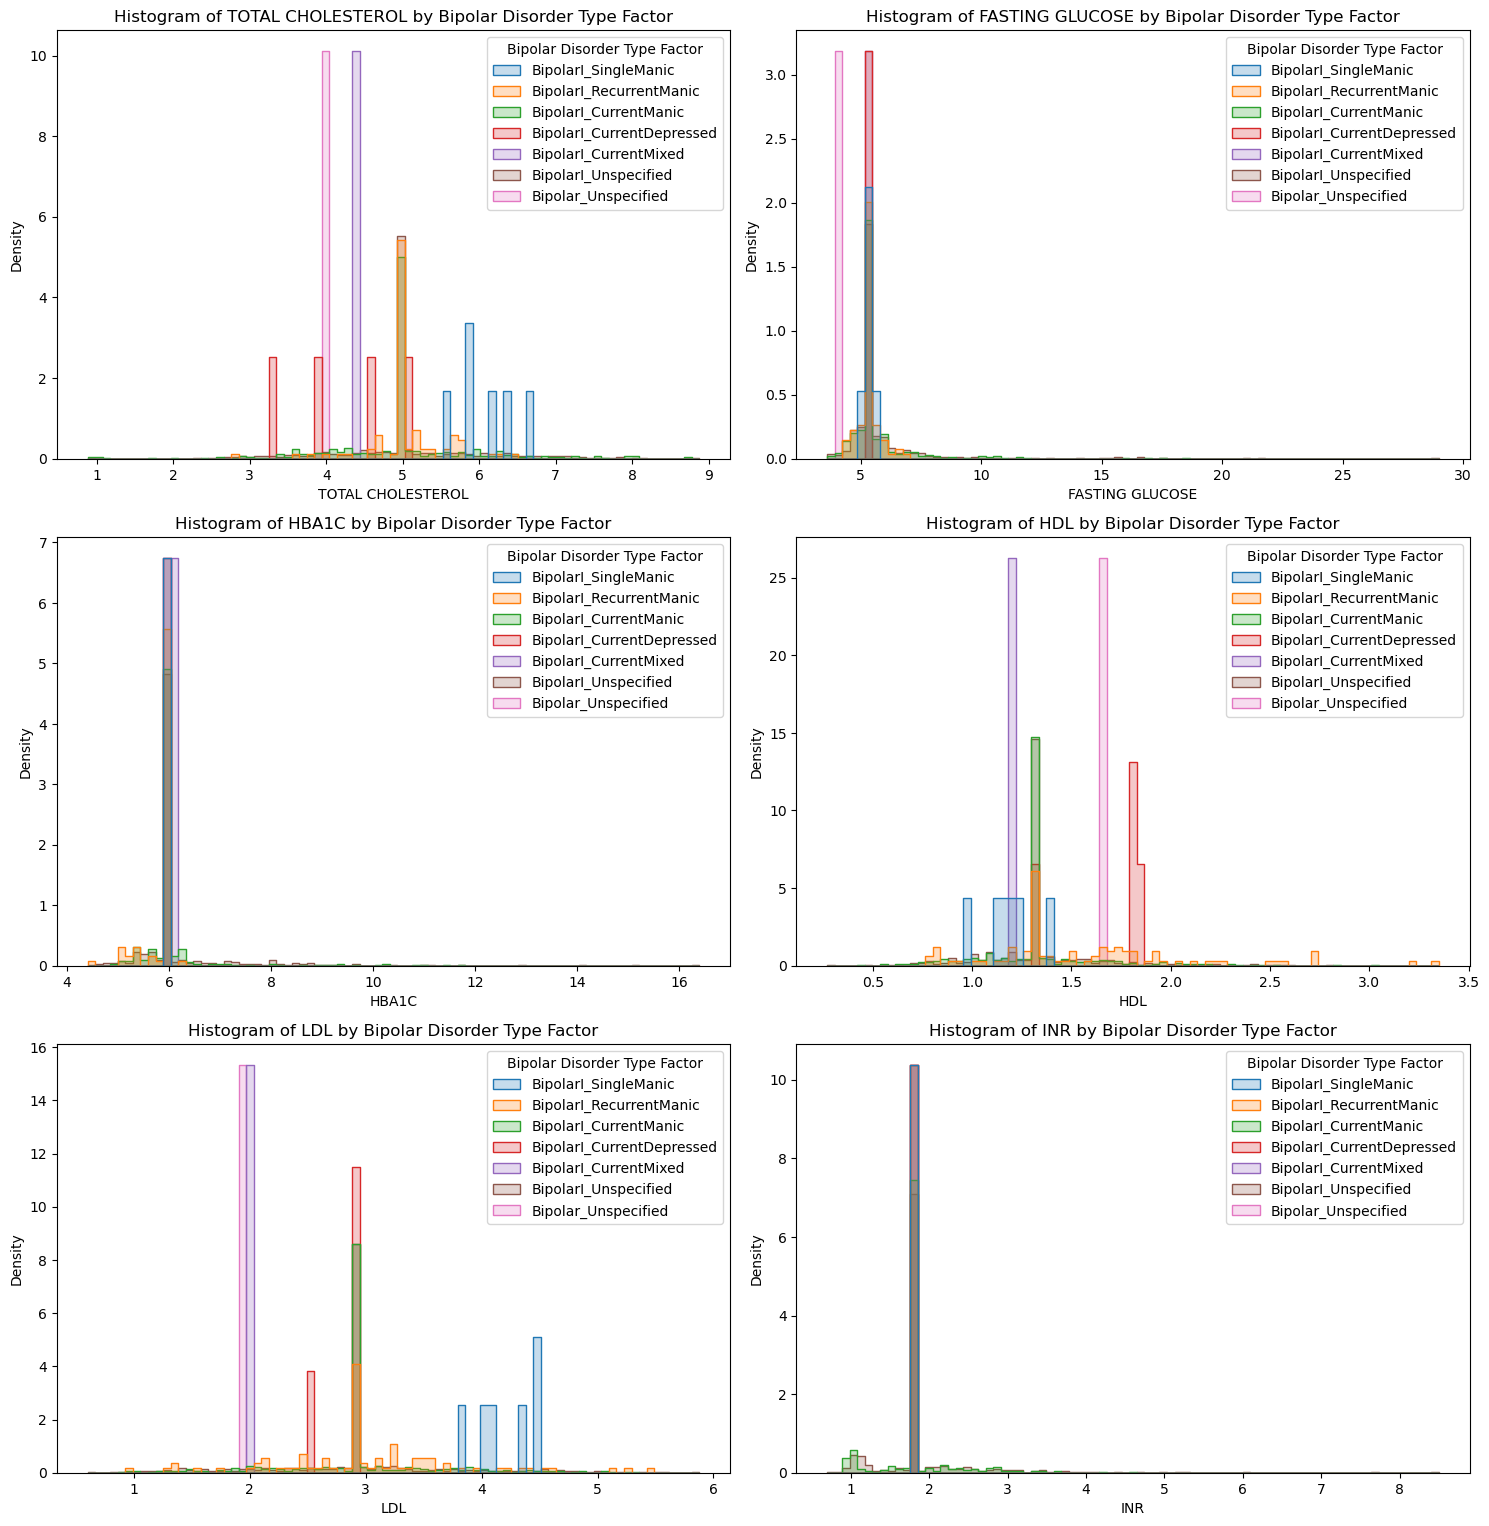

In [17]:
em.plot_grouped_histograms(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='Bipolar Disorder Type Factor')

## Based on a literature review, we found that bipolar disorder can be categorized into three states: manic, depressed, and calm. Therefore, we recategorized the original seven statuses into these three groups.

/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = data.groupby([group_hue, group_x])[var].mean().reset_index()
/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = data.groupby([group_hue, group_x])[var].mean().reset_index()
/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

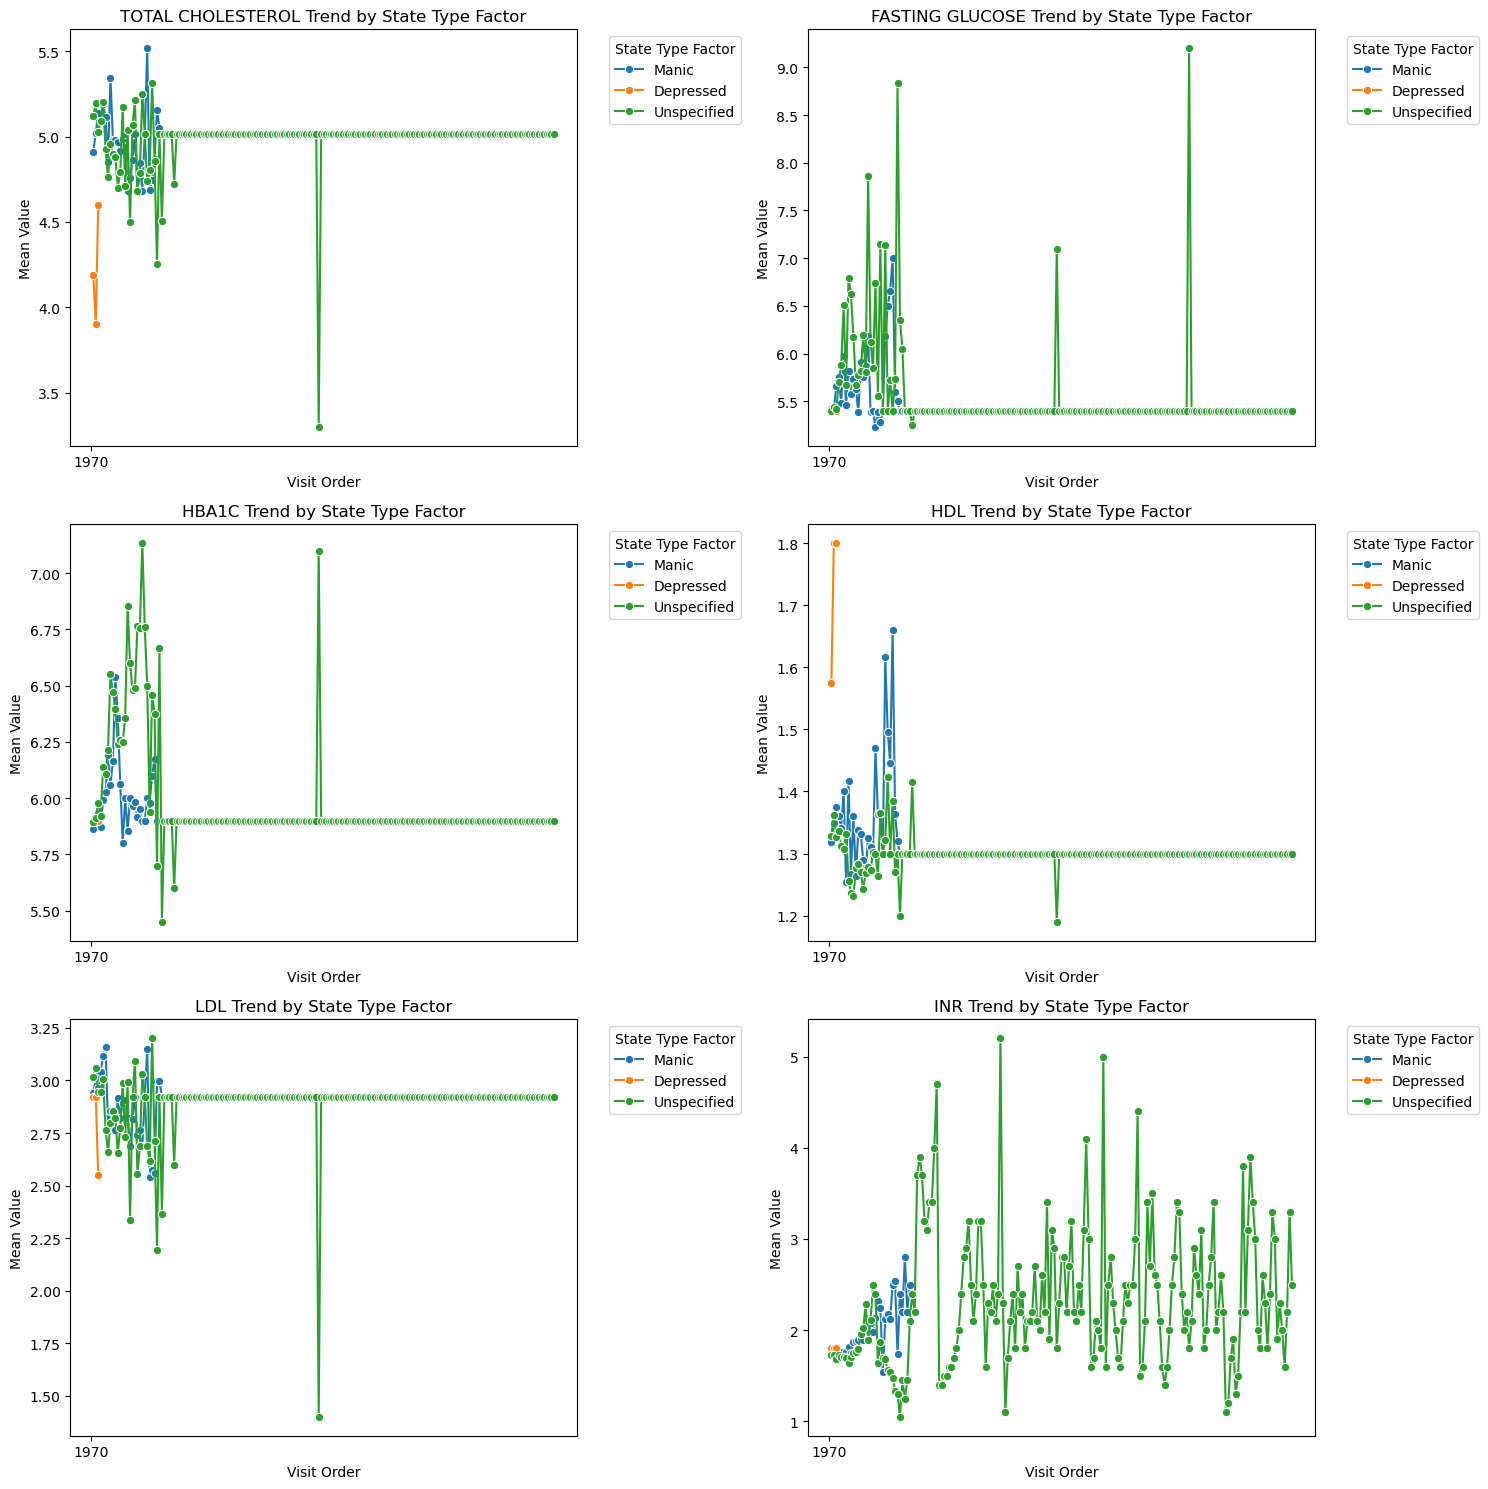

In [18]:
# mapping & encode states of bipolar disorders
state_map = {
    '296.0': 'Manic',         # BipolarI_SingleManic
    '296.1': 'Manic',         # BipolarI_RecurrentManic
    '296.4': 'Manic',         # BipolarI_CurrentManic
    '296.5': 'Depressed',     # BipolarI_CurrentDepressed
    '296.6': 'Manic',         # BipolarI_CurrentMixed (assigned to Manic, can adjust if needed)
    '296.7': 'Unspecified',   # BipolarI_Unspecified
    '296.8': 'Unspecified'    # Bipolar_Unspecified
}

state_order = ['Manic', 'Depressed', 'Unspecified']

df = em.map_encode(
    data=df,
    code='DiagnosisCode_calc',
    mapping_dict=state_map,
    ordered_levels=state_order,
    new_label='State Type',
    new_factor='State Type Factor',
    new_num='State Type Num'
)
# visualize states of bipolar disorder
em.plot_grouped_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    group_x='VisitOrder',
    group_hue='State Type Factor',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)

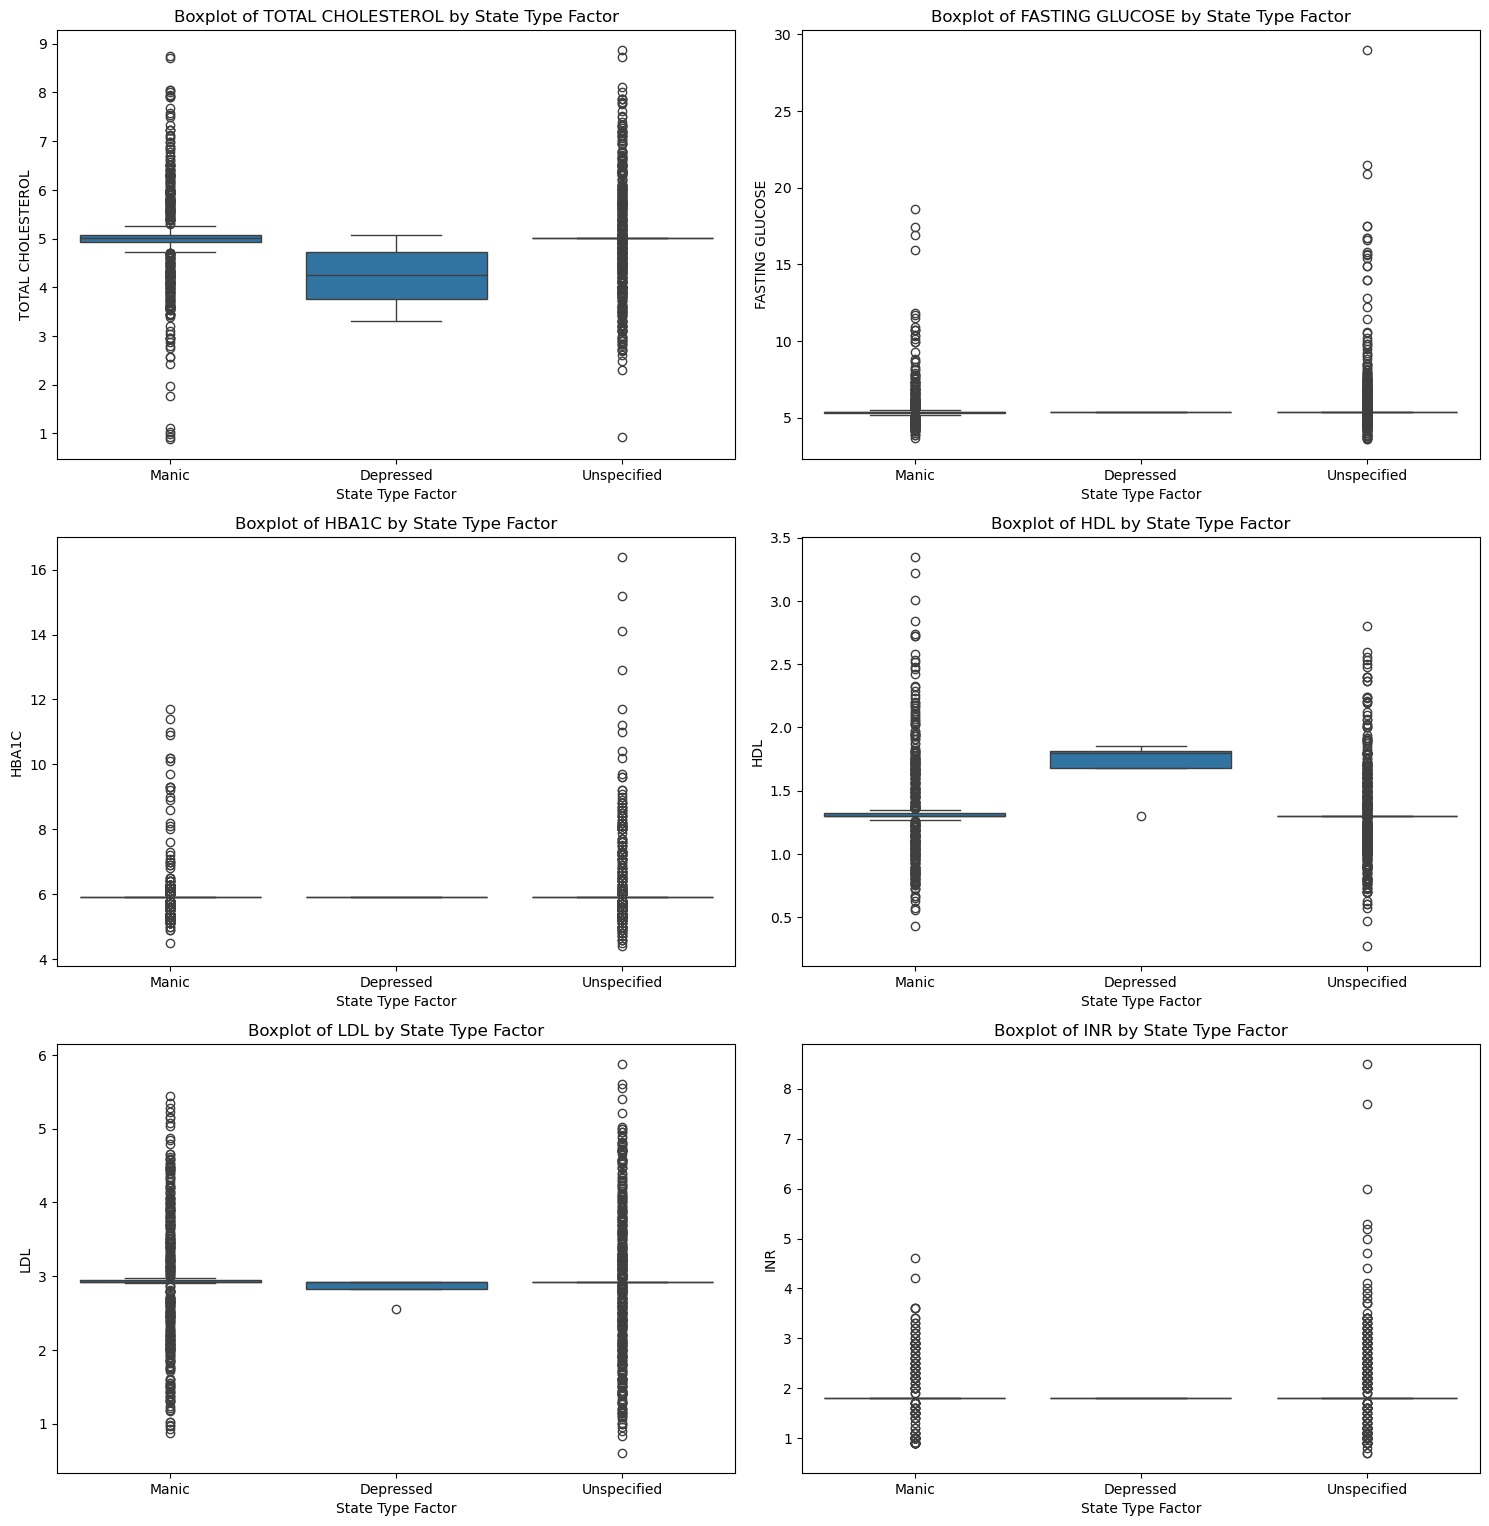

In [19]:
em.plot_grouped_boxplots(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='State Type Factor')

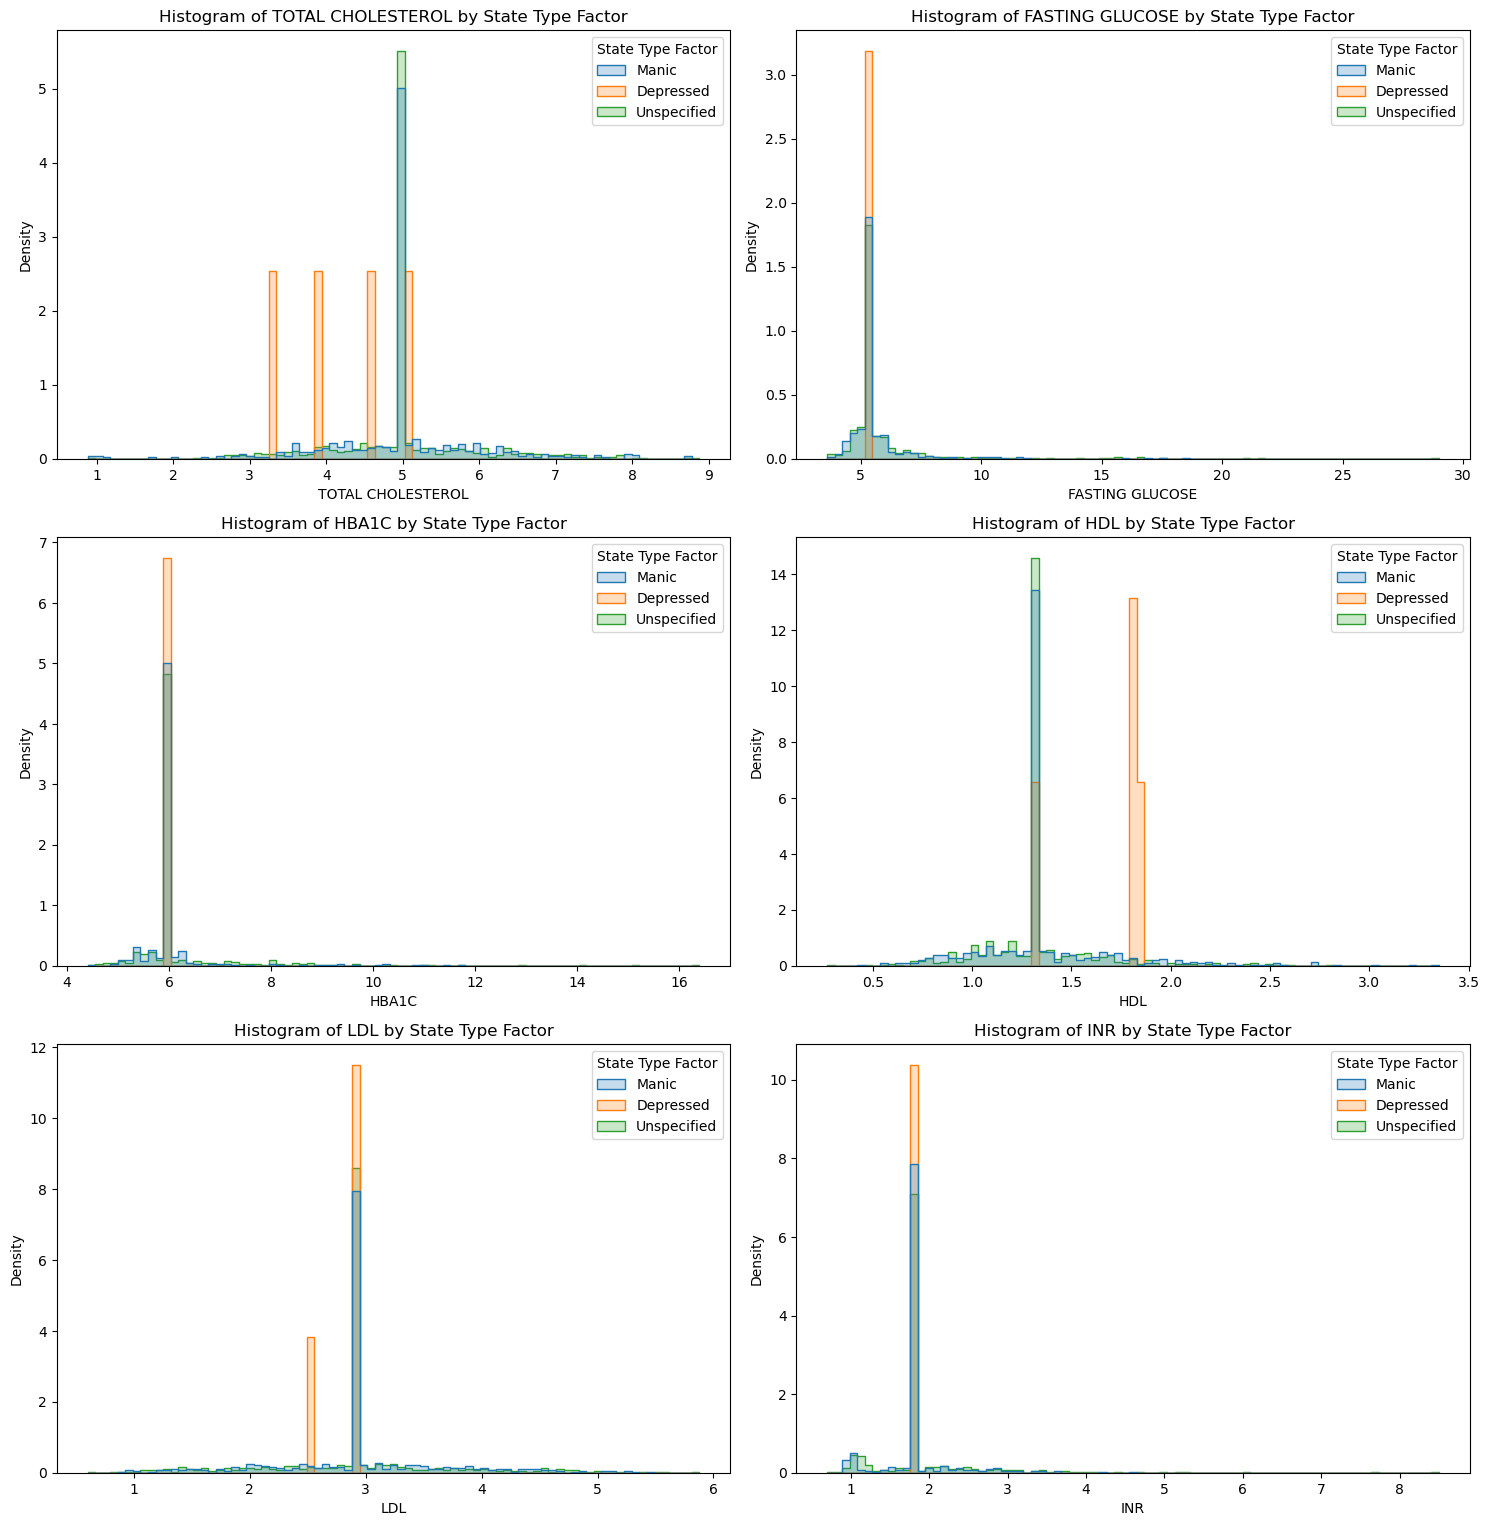

In [20]:
em.plot_grouped_histograms(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='State Type Factor')

## Perform the Kruskal-Wallis non-parametric test for each laboratory indicator to determine whether there are significant differences in the distributions of the indicators among different subtypes.

In [22]:
# Kruskal-Wallis Test to see whether there are significant differences in the variable across multiple State_factor groups.
em.kruskal_test(df, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
             group_col='Bipolar Disorder Type Factor')

TOTAL CHOLESTEROL: H=18.041, p=0.0012
FASTING GLUCOSE: H=3.992, p=0.2623
HBA1C: H=7.748, p=0.0208
HDL: H=41.204, p=0.0000
LDL: H=21.505, p=0.0003
INR: H=1.302, p=0.2539


/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:146: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = df_var.groupby(group_col)[var].count()


,variable,n_groups,H_stat,p_value
0,TOTAL CHOLESTEROL,5,18.040769,1.211661e-03
1,FASTING GLUCOSE,4,3.992393,2.622868e-01
2,HBA1C,3,7.748107,2.077400e-02
3,HDL,5,41.204346,2.438301e-08
4,LDL,5,21.505389,2.513631e-04
5,INR,2,1.301704,2.539023e-01


In [23]:
em.kruskal_test(df, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
             group_col='State Type Factor')

TOTAL CHOLESTEROL: H=3.043, p=0.2184
FASTING GLUCOSE: H=1.820, p=0.1773
HBA1C: H=1.371, p=0.2417
HDL: H=7.390, p=0.0248
LDL: H=1.751, p=0.4168
INR: H=1.194, p=0.2746


/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:146: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = df_var.groupby(group_col)[var].count()


,variable,n_groups,H_stat,p_value
0,TOTAL CHOLESTEROL,3,3.043159,0.218367
1,FASTING GLUCOSE,2,1.820028,0.177310
2,HBA1C,2,1.370632,0.241703
3,HDL,3,7.390497,0.024841
4,LDL,3,1.750528,0.416752
5,INR,2,1.193866,0.274551


## random forest to see the correlation between lab test and subtypes of bipolar disorder

Best Parameters from GridSearchCV:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Precision (macro): 0.761

 Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       188
           1       0.86      0.95      0.90       188
           2       0.71      0.65      0.68       189
           5       0.69      0.68      0.68       188

    accuracy                           0.82       753
   macro avg       0.81      0.82      0.81       753
weighted avg       0.81      0.82      0.81       753

Confusion Matrix (Raw Counts):

[[187   0   0   1]
 [  0 178   5   5]
 [  1  14 123  51]
 [  1  14  46 127]]


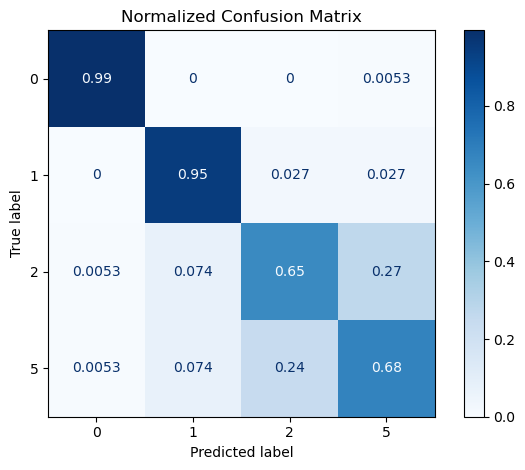

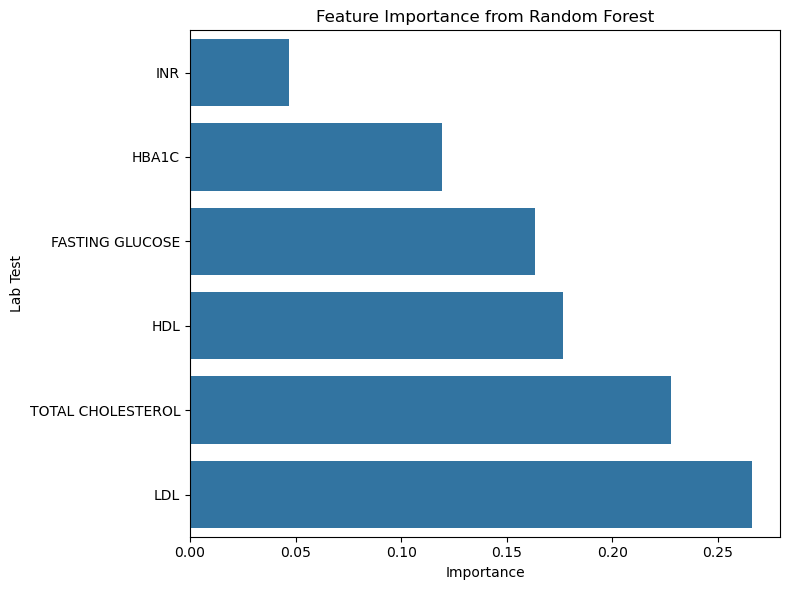


 Cross-Validated Precision (macro): 0.737 ± 0.032


In [24]:
# random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

# ---------------------------
# Step 1: Data Preprocessing
# ---------------------------
lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR']

df_clean = df.dropna(subset=lab_vars + ['Bipolar Disorder Type Factor'])

# Encode target as numeric codes
df_clean['Bipolar Disorder Type Factor'] = pd.Categorical(df_clean['Bipolar Disorder Type Factor']).codes

# Filter out classes with < 5 samples
class_counts = df_clean['Bipolar Disorder Type Factor'].value_counts()
valid_classes = class_counts[class_counts >= 5].index.tolist()
df_filtered = df_clean[df_clean['Bipolar Disorder Type Factor'].isin(valid_classes)].copy()

X = df_filtered[lab_vars]
y = df_filtered['Bipolar Disorder Type Factor']

# ---------------------------
# Step 2: Scale features
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# Step 3: Apply SMOTE
# ---------------------------
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# ---------------------------
# Step 4: Train/Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, stratify=y_resampled, test_size=0.2, random_state=42
)

# ---------------------------
# Step 5: Hyperparameter Tuning
# ---------------------------
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring='precision_macro',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters from GridSearchCV:")
print(grid_search.best_params_)
print(f"Best CV Precision (macro): {grid_search.best_score_:.3f}")

# ---------------------------
# Step 6: Final Model Evaluation
# ---------------------------
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix (Raw Counts):\n")
print(confusion_matrix(y_test, y_pred))

# Normalized Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap="Blues", normalize='true')
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# ---------------------------
# Step 7: Feature Importance
# ---------------------------
importances = pd.Series(best_rf.feature_importances_, index=lab_vars).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Lab Test")
plt.tight_layout()
plt.show()

# ---------------------------
# Step 8: Cross-validated Precision
# ---------------------------
cv_scores = cross_val_score(best_rf, X_resampled, y_resampled, cv=5, scoring='precision_macro')
print(f"\n Cross-Validated Precision (macro): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
